# Modèle 3 — XGBoost (Gradient Boosting)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK


## Chargement des données preprocessées

Mêmes données que les modèles précédents.
On charge les fichiers .npy générés par le preprocessing.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")


Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Tâche 1 — Classification du Churn


In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
# TÂCHE 1 — CLASSIFICATION

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Données déjà équilibrées par undersampling
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Entraînement sur les données rééquilibrées (undersampling)
xgb_clf.fit(X_train_under, y_train_clf_under)

y_pred_under  = xgb_clf.predict(X_test)
y_proba_under = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_clf    = y_pred_under
y_proba_clf = xgb_clf.predict_proba(X_test)[:, 1]

print(" Modèle entraîné !")
print(f"\n Résultats — XGBoost (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
xgb_clf_smote = xgb_clf.__class__(**xgb_clf.get_params())
xgb_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = xgb_clf_smote.predict(X_test)
y_proba_smote = xgb_clf_smote.predict_proba(X_test)[:, 1]

print(f"=== XGBoost — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_smote):.4f}")

# Sélection du meilleur
f1_under = recall_score(y_test_clf, y_pred_clf)
f1_smote = recall_score(y_test_clf, y_pred_smote)
if f1_smote >= f1_under:
    xgb_clf = xgb_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    best_technique = 'Undersampling'
print(f"\n→ Meilleure technique : {best_technique} (Recall={max(f1_under, f1_smote):.4f})")

 Modèle entraîné !

 Résultats — XGBoost (Classification)
   Accuracy  : 0.7190
   Precision : 0.2383
   Recall    : 0.7990
   F1-Score  : 0.3671
   ROC-AUC   : 0.7837

=== XGBoost — SMOTE ===
   Accuracy  : 0.8890
   Precision : 0.2632
   Recall    : 0.0490
   F1-Score  : 0.0826
   ROC-AUC   : 0.7718
   PR-AUC    : 0.2532

→ Meilleure technique : Undersampling (Recall=0.7990)


## Approche niveau modèle — `class_weight='balanced'`

En complément du rééchantillonnage, on expérimente une approche au niveau du modèle : `class_weight='balanced'` pénalise davantage les erreurs sur la classe minoritaire (churners) en pondérant chaque classe inversement proportionnellement à sa fréquence.

**Avantage** : pas de modification des données, pas d'overfitting lié aux données synthétiques.  
**Limite** : peut réduire la précision sur la classe majoritaire.

On compare les 3 approches : Undersampling / SMOTE / class_weight='balanced'.

scale_pos_weight = 7183/817 = 8.79
=== XGBoost — scale_pos_weight=balanced ===
   Accuracy  : 0.8645
   Precision : 0.2657
   Recall    : 0.1863
   F1-Score  : 0.2190
   ROC-AUC   : 0.7590
   PR-AUC    : 0.2372

=== Comparaison des 3 approches ===
Approche                    Recall  Precision       F1   ROC-AUC   PR-AUC
------------------------------------------------------------------------
Undersampling               0.7990     0.2383   0.3671    0.7837   0.2662
SMOTE                       0.0490     0.2632   0.0826    0.7718   0.2532
scale_pos_weight=auto       0.1863     0.2657   0.2190    0.7590   0.2372


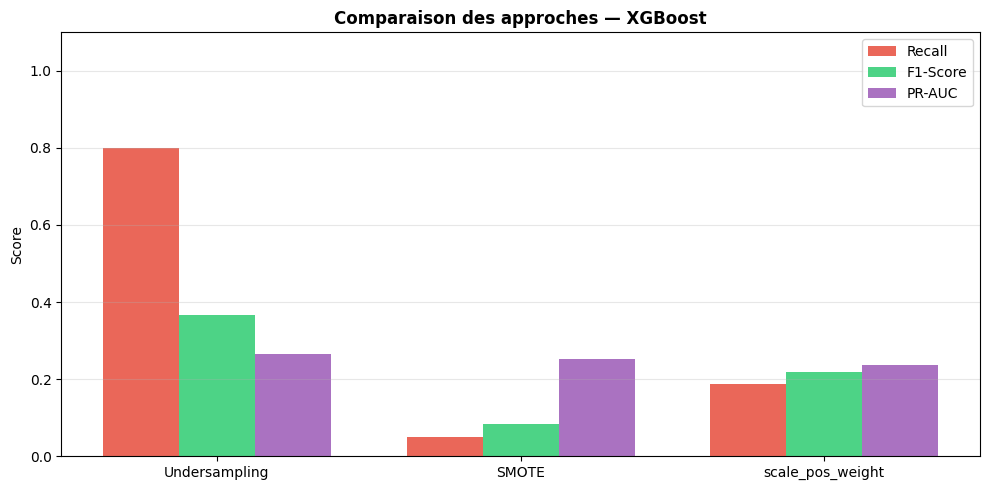

In [4]:
# APPROCHE NIVEAU MODÈLE — scale_pos_weight (équivalent class_weight pour XGBoost)

# XGBoost n'a pas class_weight, on utilise scale_pos_weight = n_neg / n_pos
n_neg = int((y_train_clf == 0).sum())
n_pos = int((y_train_clf == 1).sum())
spw   = round(n_neg / n_pos, 2)
print(f'scale_pos_weight = {n_neg}/{n_pos} = {spw}')

xgb_clf_cw = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,   # pondération automatique
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_clf_cw.fit(X_train, y_train_clf)
y_pred_cw  = xgb_clf_cw.predict(X_test)
y_proba_cw = xgb_clf_cw.predict_proba(X_test)[:, 1]

print('=== XGBoost — scale_pos_weight=balanced ===')
print(f'   Accuracy  : {accuracy_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Precision : {precision_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Recall    : {recall_score(y_test_clf, y_pred_cw):.4f}')
print(f'   F1-Score  : {f1_score(y_test_clf, y_pred_cw):.4f}')
print(f'   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw):.4f}')
print(f'   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw):.4f}')

print('\n=== Comparaison des 3 approches ===')
header = f"{'Approche':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 72)
for name, y_pred, y_proba in [
    ('Undersampling',          y_pred_under, y_proba_under),
    ('SMOTE',                  y_pred_smote, y_proba_smote),
    ('scale_pos_weight=auto',  y_pred_cw,    y_proba_cw),
]:
    print(f'{name:<25} '
          f'{recall_score(y_test_clf, y_pred):>8.4f} '
          f'{precision_score(y_test_clf, y_pred):>10.4f} '
          f'{f1_score(y_test_clf, y_pred):>8.4f} '
          f'{roc_auc_score(y_test_clf, y_proba):>9.4f} '
          f'{average_precision_score(y_test_clf, y_proba):>8.4f}')

approaches = ['Undersampling', 'SMOTE', 'scale_pos_weight']
recalls    = [recall_score(y_test_clf, y_pred_under), recall_score(y_test_clf, y_pred_smote), recall_score(y_test_clf, y_pred_cw)]
f1s        = [f1_score(y_test_clf, y_pred_under),     f1_score(y_test_clf, y_pred_smote),     f1_score(y_test_clf, y_pred_cw)]
pr_aucs    = [average_precision_score(y_test_clf, y_proba_under), average_precision_score(y_test_clf, y_proba_smote), average_precision_score(y_test_clf, y_proba_cw)]

x = np.arange(len(approaches))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recalls, width, label='Recall',  color='#e74c3c', alpha=0.85)
ax.bar(x,         f1s,     width, label='F1-Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, pr_aucs, width, label='PR-AUC',  color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des approches — XGBoost', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/xgb_approaches_comparison.png', dpi=150)
plt.show()


## 🔴 Matrice de Confusion


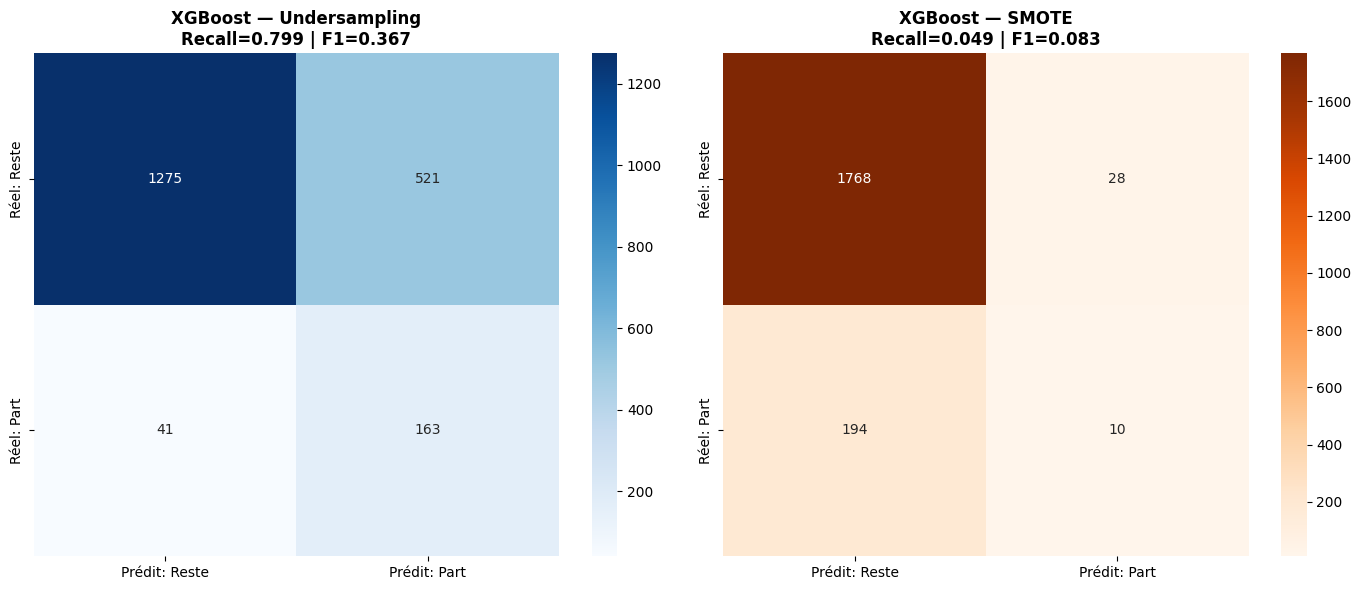


Meilleur modèle (Undersampling) :
   FN (churners manqués) : 41
   TP (churners détectés) : 163


In [5]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'XGBoost — Undersampling', 'Blues'),
    (y_pred_smote, 'XGBoost — SMOTE', 'Oranges'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/xgb_confusion_matrix.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   FN (churners manqués) : {fn}")
print(f"   TP (churners détectés) : {tp}")

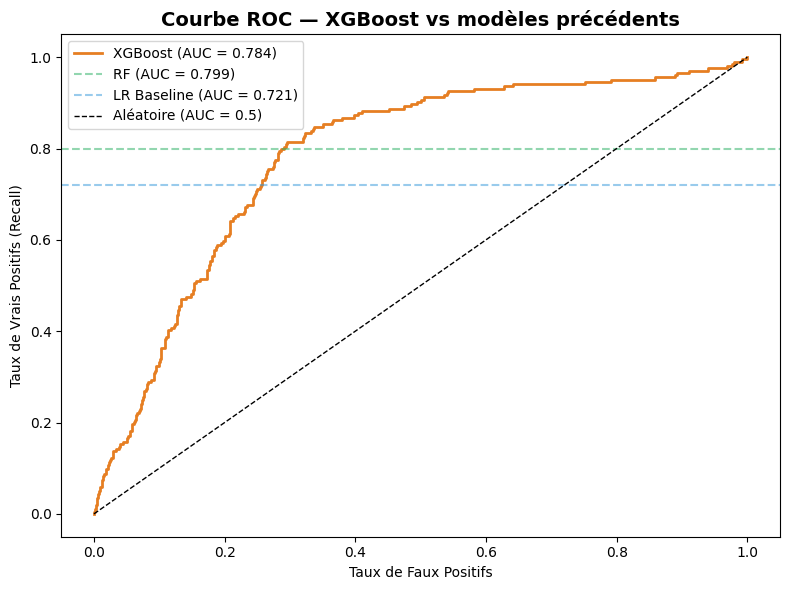

In [6]:
# COURBE ROC — Comparaison tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
         label=f'XGBoost (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR Baseline (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — XGBoost vs modèles précédents',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_roc_curve.png', dpi=150)
plt.show()

## Ajustement du Seuil de Décision

Par défaut, un classifieur utilise un seuil de 0.5. Dans un contexte déséquilibré (10% de churners), ce seuil n'est pas optimal car il favorise la classe majoritaire.

On teste différents seuils et on mesure l'impact sur :
- **Recall** : taux de churners détectés (minimiser les FN)
- **Precision** : taux de vrais churners parmi les alertes (minimiser les FP)
- **F1-Score** : compromis precision/recall
- **FP / FN** : impact métier direct

Seuil par défaut (0.5) :
  Recall=0.799 | Precision=0.238 | F1=0.367 | FP=521 | FN=41

Seuil optimal (0.5) :
  Recall=0.799 | Precision=0.238 | F1=0.367 | FP=521 | FN=41


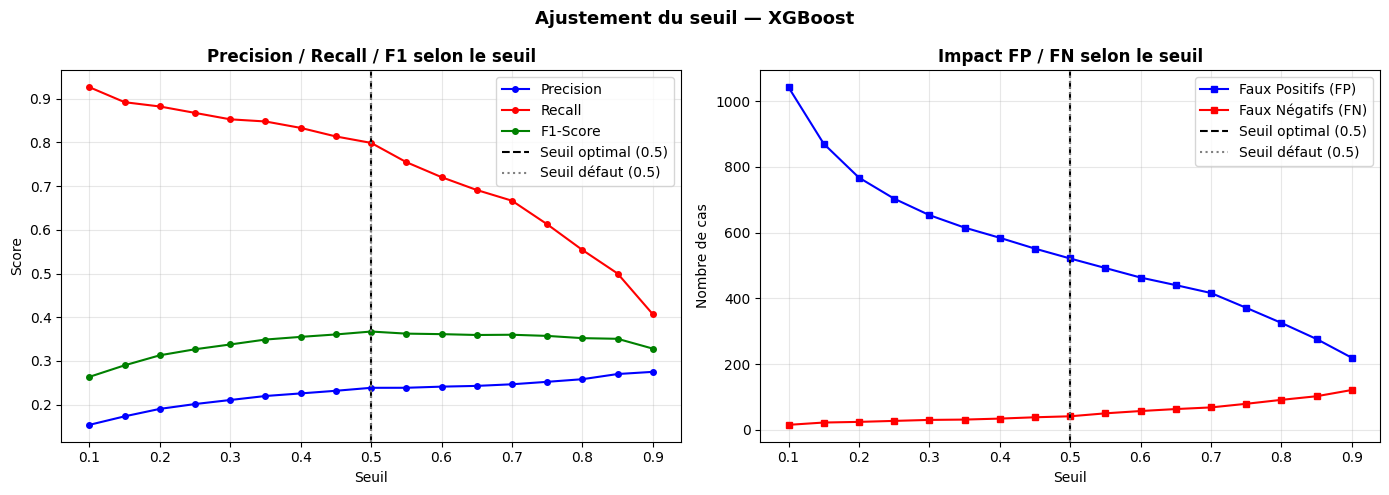

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.153534 0.926471 0.263415 1042  15 189
  0.15   0.173004 0.892157 0.289809  870  22 182
  0.20   0.190074 0.882353 0.312772  767  24 180
  0.25   0.201136 0.867647 0.326568  703  27 177
  0.30   0.210399 0.852941 0.337536  653  30 174
  0.35   0.219543 0.848039 0.348790  615  31 173
  0.40   0.225464 0.833333 0.354906  584  34 170
  0.45   0.231520 0.813725 0.360478  551  38 166
  0.50   0.238304 0.799020 0.367117  521  41 163
  0.55   0.238390 0.754902 0.362353  492  50 154
  0.60   0.240984 0.720588 0.361179  463  57 147
  0.65   0.242685 0.691176 0.359236  440  63 141
  0.70   0.246377 0.666667 0.359788  416  68 136
  0.75   0.252016 0.612745 0.357143  371  79 125
  0.80   0.257991 0.553922 0.352025  325  91 113
  0.85   0.269841 0.500000 0.350515  276 102 102
  0.90   0.274834 0.406863 0.328063  219 121  83

Prédictions mises à jour avec seuil=0.5
  Recall final  : 0.7990
  F1 final      : 0.3671


In [7]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil optimal = max F1
best_idx = df_thresh['f1'].idxmax()
best_t   = df_thresh.loc[best_idx, 'seuil']

# Affichage comparaison seuil 0.5 vs optimal
rows_05 = df_thresh[df_thresh['seuil'] == 0.5]
if len(rows_05) > 0:
    r05 = rows_05.iloc[0]
    print(f"Seuil par défaut (0.5) :")
    print(f"  Recall={r05['recall']:.3f} | Precision={r05['precision']:.3f} | F1={r05['f1']:.3f} | FP={int(r05['FP'])} | FN={int(r05['FN'])}")

br = df_thresh.loc[best_idx]
print(f"\nSeuil optimal ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil optimal
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")


## Validation Croisée Stratifiée (Stratified K-Fold)

Un simple split train/test peut être sensible au hasard de la partition. La validation croisée stratifiée permet d'obtenir une estimation plus robuste des performances en préservant les proportions de classes (10% churners) dans chaque fold.

**Pourquoi stratifiée ?**  
Avec seulement 10% de churners, un fold non stratifié pourrait se retrouver avec très peu (ou aucun) churner, rendant les métriques instables.

On évalue le meilleur modèle (issu de la comparaison Undersampling vs SMOTE) sur 5 folds stratifiés et on reporte mean ± std pour chaque métrique.

Stratified K-Fold (5 folds) — XGBoost
--------------------------------------------------
  recall       : 0.0685 ± 0.0117
  precision    : 0.3691 ± 0.0443
  f1           : 0.1153 ± 0.0177
  roc_auc      : nan ± nan
  pr_auc       : nan ± nan

Comparaison avec le score test set (seuil optimisé) :
  recall     : 0.7990  (test set)
  f1         : 0.3671  (test set)
  roc_auc    : 0.7837  (test set)
  pr_auc     : 0.2662  (test set)


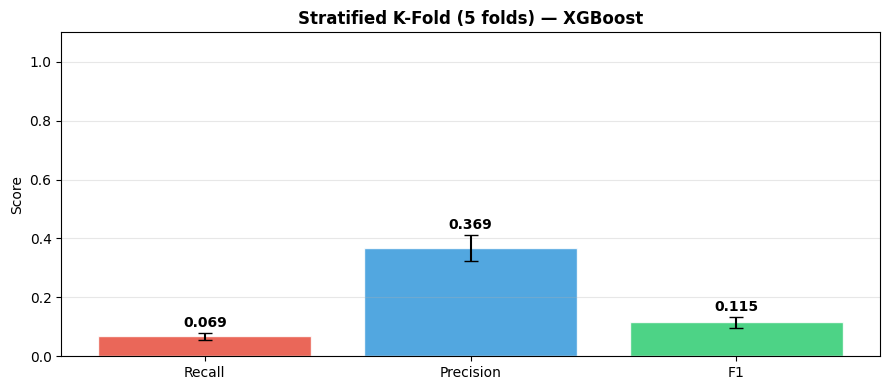

In [8]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1':        make_scorer(f1_score),
    'roc_auc':   make_scorer(roc_auc_score, needs_proba=True),
    'pr_auc':    make_scorer(average_precision_score, needs_proba=True),
}

# Pipeline : rééquilibrage SMOTE à l'intérieur du fold (évite le data leakage)
pipe = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('clf',     XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)),
])

cv_results = cross_validate(
    pipe,
    X_train, y_train_clf,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print(f'Stratified K-Fold ({N_SPLITS} folds) — XGBoost')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

# Comparaison avec le score sur le test set
print('\nComparaison avec le score test set (seuil optimisé) :')
print(f'  recall     : {recall_score(y_test_clf, y_pred_clf):.4f}  (test set)')
print(f'  f1         : {f1_score(y_test_clf, y_pred_clf):.4f}  (test set)')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')

# Visualisation mean ± std
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means = [cv_results[f'test_{k}'].mean() for k in metrics_keys]
stds  = [cv_results[f'test_{k}'].std()  for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics_labels, means, yerr=stds, capsize=5,
              color=['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22'],
              edgecolor='white', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stratified K-Fold (5 folds) — XGBoost', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/xgb_kfold_cv.png', dpi=150)
plt.show()


## 🔍 Feature Importance XGBoost


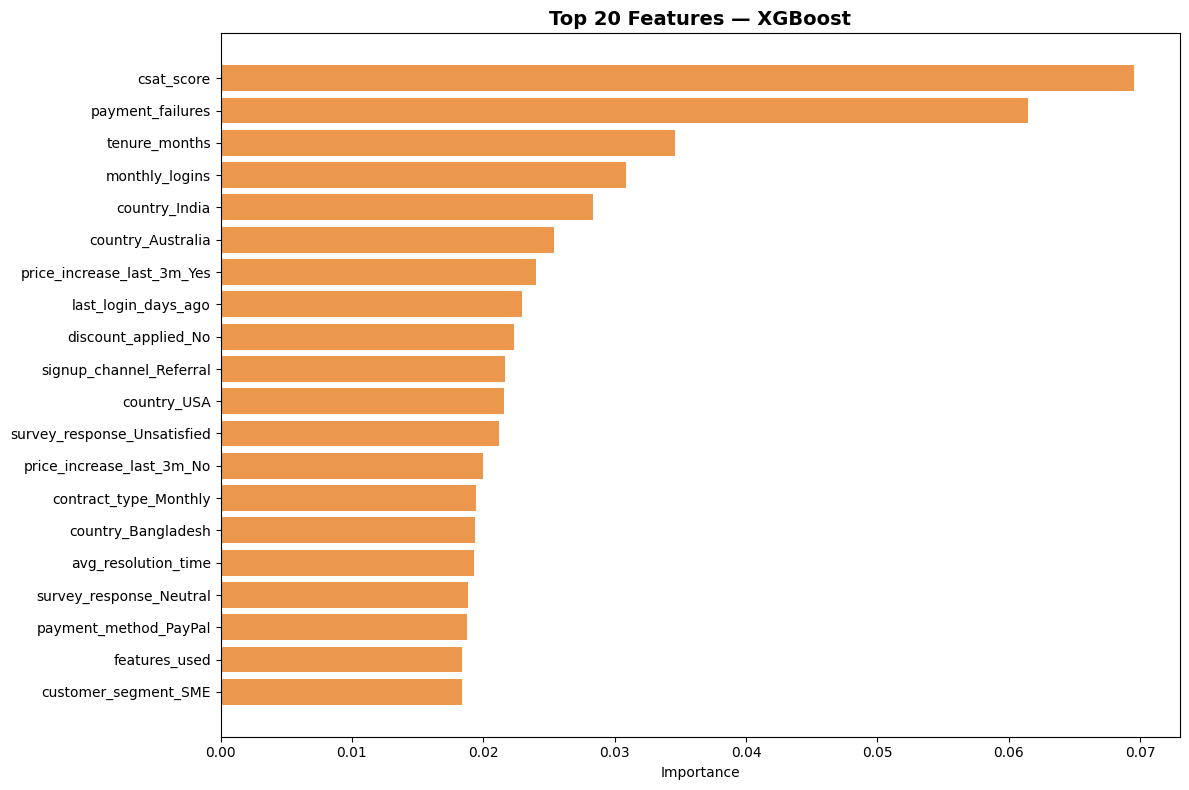


 Top 10 features les plus importantes :
   1. csat_score                          : 0.0696
   2. payment_failures                    : 0.0615
   3. tenure_months                       : 0.0346
   4. monthly_logins                      : 0.0308
   5. country_India                       : 0.0283
   6. country_Australia                   : 0.0254
   7. price_increase_last_3m_Yes          : 0.0240
   8. last_login_days_ago                 : 0.0229
   9. discount_applied_No                 : 0.0224
   10. signup_channel_Referral             : 0.0216


In [9]:
# FEATURE IMPORTANCE

importances = xgb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh(range(20),
         importances[indices][::-1],
         color='#e67e22', alpha=0.8)
plt.yticks(range(20),
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_feature_importance.png', dpi=150)
plt.show()

print("\n Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque


In [10]:
# TÂCHE 2 — RÉGRESSION XGBoost

X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.5,
    min_child_weight=20,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_reg.fit(X_train_reg, y_train_reg_log)

y_pred_reg_log = xgb_reg.predict(X_test)
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print("Modèle de régression entraîné !")
print(f"\nRésultats — XGBoost Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — XGBoost Regression (churners uniquement)
   MAE  : 166.09 €
   RMSE : 370.00 €
   R²   : 0.8485


In [11]:
# SAUVEGARDE

print(f'Sauvegarde du meilleur modèle : {best_technique}')
joblib.dump(xgb_clf, '../models/xgb_classification.pkl')
joblib.dump(xgb_reg, '../models/xgb_regression.pkl')

results_clf = {
    'model'    : 'XGBoost',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc'  : average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'XGBoost Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/xgb_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/xgb_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du meilleur modèle : Undersampling
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.7190
   precision  : 0.2383
   recall     : 0.7990
   f1         : 0.3671
   roc_auc    : 0.7837
   pr_auc     : 0.2662


## Synthèse — XGBoost
